<a href="https://colab.research.google.com/github/Mohamad-Selawy/Python/blob/master/Data%20Analysis/Level%203/Part_2_Visualization_with_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Visualization with Seaborn: Beyond Matplotlib

---

## Setup and Data Loading

First, let's import the necessary libraries and load our dataset. We'll be using a Sales Forecasting dataset throughout this notebook to ground our learning in a real-world business context.

In [2]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For basic plotting and customization (Seaborn is built on it)
import seaborn as sns # For advanced statistical data visualization
import kagglehub # For downloading datasets from Kaggle

# Configure Matplotlib for better aesthetics (optional, but good practice)
plt.style.use('ggplot') # Use ggplot style for plots
plt.rcParams['figure.figsize'] = (10, 6) # Set default figure size

### Download and Load the Dataset

We'll use the 'sales-forecasting' dataset from KaggleHub. This dataset contains sales records that we can analyze to understand trends, patterns, and relationships.

In [3]:
# Download the dataset from KaggleHub
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

data_file_path = f"{path}/train.csv" # Adjust filename if different

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(data_file_path)

Using Colab cache for faster access to the 'sales-forecasting' dataset.


### Initial Data Exploration

Let's get a first look at our data to understand its structure, types, and summary statistics. This is crucial before we start visualizing.

In [4]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

# Generate descriptive statistics of the DataFrame's numerical columns
display(df.describe())

# Display the shape of the DataFrame (number of rows, number of columns)
print(f"\n--- Dataset Shape: {df.shape} (rows, columns) ---")

# Display the column names
print(df.columns.tolist())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000



--- Dataset Shape: (9800, 18) (rows, columns) ---
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


### Data Preprocessing: Date Columns

Before diving into visualizations, it's good practice to ensure our data types are correct. We noticed that 'Order Date' and 'Ship Date' are currently `object` types. For any time-based analysis or plotting, these need to be converted to `datetime` objects.

In [5]:
df = df.dropna()
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Profit'] = df['Sales'] * 0.2
# Verify the conversion
print("\n--- DataFrame Info after Date Conversion ---")
df.info()


--- DataFrame Info after Date Conversion ---
<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   

## Section 1 — Introduction to Seaborn

Now that our data is ready, let's explore Seaborn! As we discussed, Seaborn is a powerful Python data visualization library built on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

### What is Seaborn and Why is it Popular?

**Seaborn** is essentially a wrapper around Matplotlib, designed to make creating complex statistical plots much easier and visually appealing. Here's why it's so popular among data analysts:

1.  **Aesthetic Defaults:** Seaborn comes with beautiful default styles and color palettes that make your plots look professional without much effort.
2.  **High-Level Interface:** It simplifies the process of plotting by abstracting away much of the underlying Matplotlib complexity. You often need fewer lines of code to create sophisticated plots.
3.  **Statistical Plotting:** Seaborn specializes in visualizing statistical relationships, distributions, and comparisons. It's built for understanding data patterns.


### Built-in Themes and Color Palettes

Seaborn offers various built-in themes (e.g., `'darkgrid'`, `'whitegrid'`) and color palettes to enhance plot aesthetics. For brevity, detailed examples are omitted here.

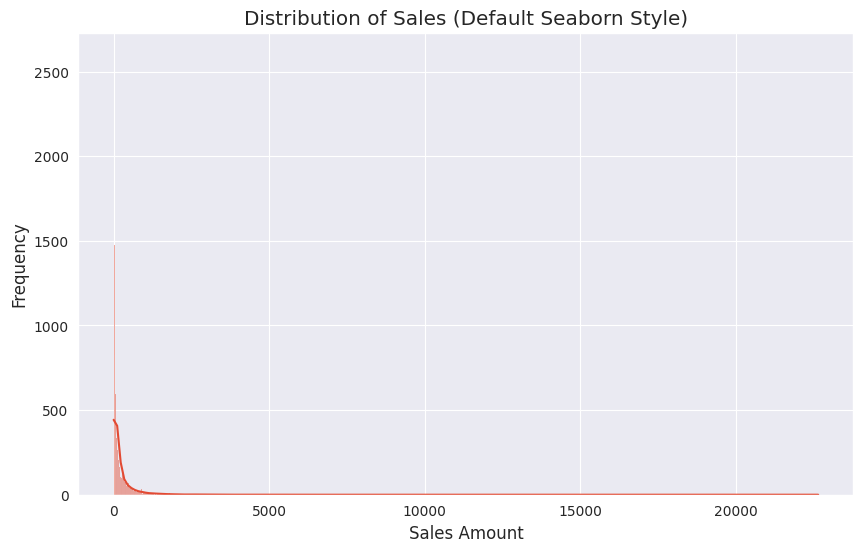

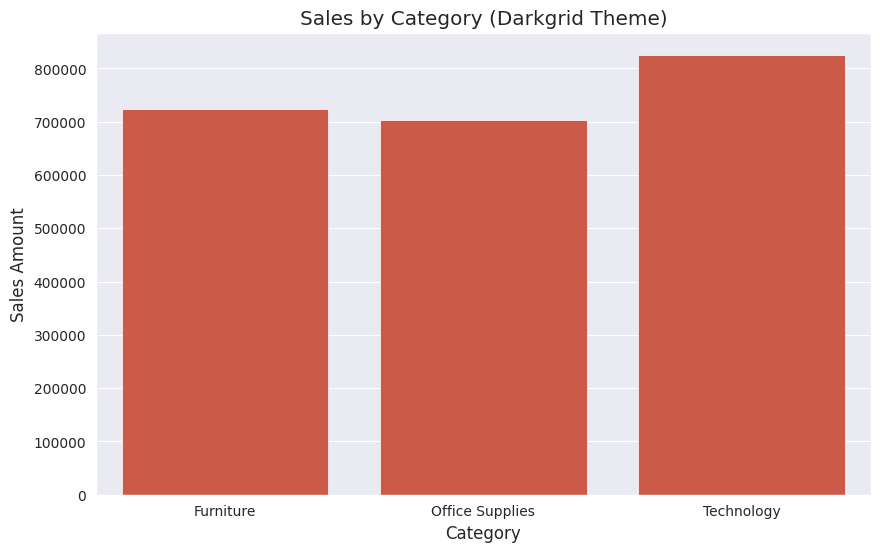

In [32]:
# Example 1: Demonstrate default Seaborn style with a simple distribution plot
# We'll use the 'Sales' column to see its distribution.

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Sales', kde=True) # kde=True adds a Kernel Density Estimate line
plt.title('Distribution of Sales (Default Seaborn Style)')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()


# Example 2: Changing Seaborn theme
# Let's try another theme like 'darkgrid'

sns.set_style('darkgrid') # Set the theme to 'darkgrid'
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Category', y='Sales', estimator=np.sum, errorbar=None) # A bar plot to show sales by categories
plt.title('Sales by Category (Darkgrid Theme)')
plt.xlabel('Category')
plt.ylabel('Sales Amount')
plt.show()

#### **Best Practice:** Resetting Styles

For consistency, it's good practice to set a preferred style at the beginning of the notebook or reset it after demonstrating different themes.

In [7]:
# Reset to default or preferred style for consistency throughout the notebook
sns.set_style('whitegrid') # A common and clean style for presentations

## Section 2 — Essential Seaborn Charts

In this section, we will explore some of the most commonly used and powerful Seaborn charts. For each chart, we will cover its purpose, when to use it (and when not to), a business example, fully commented Python code, important parameters, interpretation, and a business insight derived from the visualization.

### 1. Scatter Plot (`sns.scatterplot()`)

*   **Purpose:** To visualize the relationship between two continuous variables.
*   **When to Use It:**
    *   To identify correlations or trends between two quantitative variables.
    *   To detect outliers or clusters in the data.
    *   When you have a moderate number of data points. For very large datasets, alternatives like hexbin plots or 2D histograms might be more suitable due to overplotting.
*   **When Not to Use It:**
    *   For visualizing categorical data or a single variable's distribution.
    *   When dealing with time series, a line plot is usually more appropriate.
*   **Business Example:** Analyzing the relationship between `Sales` and `Profit` (if available, otherwise we will use `Sales` vs `Quantity` or similar proxies, or focus on a single variable's spread per category if two continuous variables aren't directly available for strong correlation example in this specific dataset without aggregation). Given our dataset, we can analyze `Sales` across different product `Category` or `Sub-Category` to see the spread.

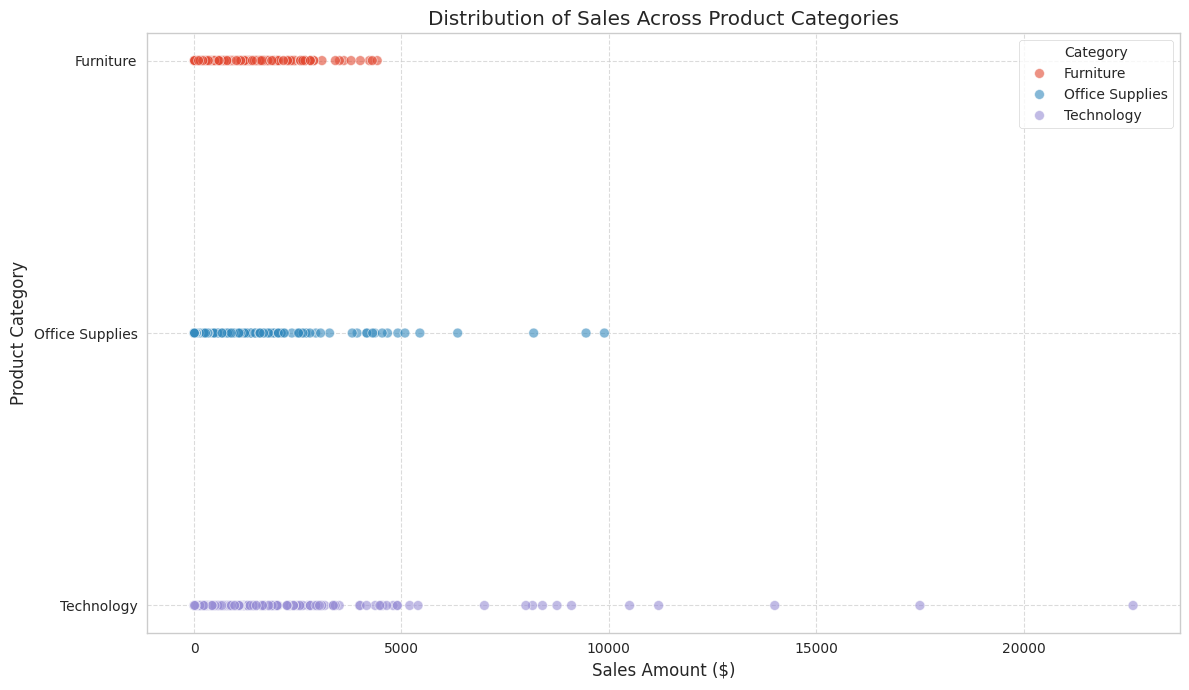

In [17]:
# Business Example: Sales distribution across Categories
# Let's visualize the distribution of sales values for each product category.
# While not a direct correlation, it helps understand the range of sales within each category.

plt.figure(figsize=(12, 7))
# Create a scatter plot using Seaborn
# x='Sales': Specifies the column for the x-axis (continuous variable)
# y='Category': Specifies the column for the y-axis (categorical variable for comparison)
# data=df: The DataFrame to draw the plot from
# hue='Category': Colors the points based on the 'Category' column, helping differentiate categories
# alpha=0.6: Sets the transparency of the points, useful for seeing overlapping points
# s=50: Sets the size of the points
sns.scatterplot(x='Sales', y='Category', data=df, hue='Category', alpha=0.6, s=50)

plt.title('Distribution of Sales Across Product Categories')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Product Category')
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better readability
plt.legend(title='Category', loc='upper right') # Place legend outside the plot
plt.tight_layout() # Adjust plot to prevent labels from overlapping
plt.show()

# Interpretation:
# This scatter plot shows individual sales transactions plotted against their respective product categories.
# We can observe the range of sales values within each category. For example, 'Technology' and 'Furniture'
# categories show a wider spread with some very high individual sales, whereas 'Office Supplies'
# generally has lower individual sales values, though it still has a wide range.

# Business Insight:
# The visualization helps in identifying which categories generate the highest individual sales and which ones
# have a broader distribution of sales values. Categories like 'Furniture' and 'Technology' often have high-value
# items, contributing to larger individual sales. 'Office Supplies', while having many transactions, typically
# involves lower-priced items. This can inform inventory decisions, pricing strategies, and marketing efforts
# tailored to each category's sales profile.

#### **Common Mistake:** Using scatter plots for too many data points without adjustments. Overplotting can make the chart unreadable. Consider `alpha` parameter, `hexbin` plots, or aggregating data for very dense scatter plots.

### 2. Line Plot (`sns.lineplot()`)

*   **Purpose:** To visualize the trend of one or more variables over time or an ordered category.
*   **When to Use It:**
    *   When one of your variables represents a sequence, such as time (dates, months, years) or an ordered category.
    *   To show how a variable changes or evolves over a continuous interval.
    *   To compare trends between different groups over time.
*   **When Not to Use It:**
    *   For comparing discrete, unordered categories.
    *   To show relationships between two continuous variables where order isn't a factor (use a scatter plot).
*   **Business Example:** Analyzing `Sales` trends over time. We will aggregate sales by `Order Date` to see how total sales change daily, weekly, or monthly.

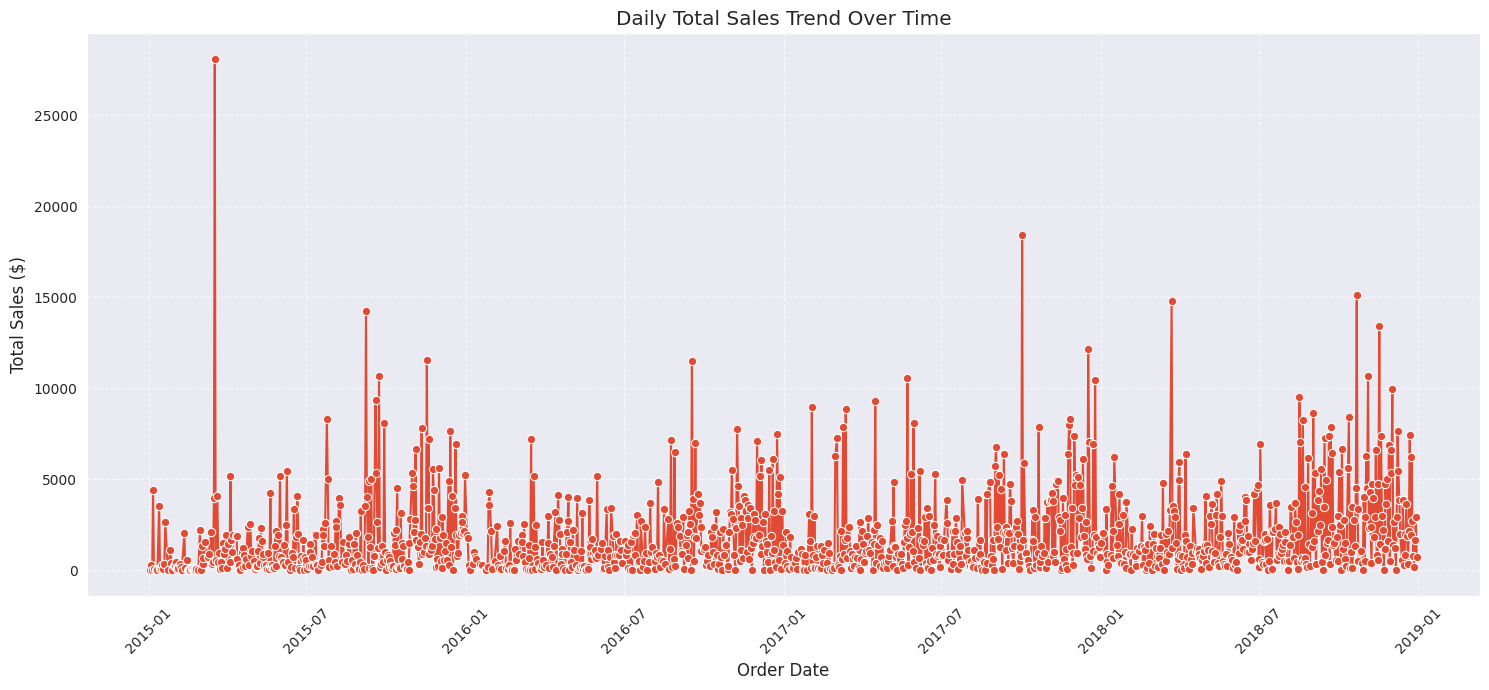

In [34]:
# Business Example: Daily Sales Trend
# First, we need to aggregate sales data by 'Order Date'.
# We'll calculate the sum of sales for each day.

daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
# Create a line plot using Seaborn
# x='Order Date': Specifies the time variable for the x-axis
# y='Sales': Specifies the continuous variable for the y-axis
# data=daily_sales: The aggregated DataFrame
# marker='o': Adds markers to each data point (optional, but good for discrete points)
# linestyle='-': Connects the markers with a solid line
# errorbar=None: Disables confidence intervals if the data contains multiple observations per x-value
#               (not strictly needed here since we aggregated, but good to know for `lineplot`)
sns.lineplot(x='Order Date', y='Sales', data=daily_sales, marker='o', linestyle='-')

plt.title('Daily Total Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate date labels for better readability
plt.tight_layout()
plt.show()

# Interpretation:
# This line plot displays the aggregate total sales for each day in our dataset. We can observe fluctuations
# and overall trends in sales over the entire period. There are clear peaks and troughs, indicating periods
# of higher and lower sales activity.

# Business Insight:
# Understanding daily sales trends is critical for demand forecasting, inventory management, and staffing.
# Peaks might correspond to promotional periods, holidays, or seasonal demands, while troughs could indicate
# slow periods or potential issues. Identifying these patterns allows businesses to proactively manage resources
# and capitalize on opportunities or mitigate risks. Further analysis could involve smoothing the trend (e.g., monthly sales)
# or breaking it down by year to see annual patterns.

### 3. Bar Plot (`sns.barplot()`)

*   **Purpose:** To display and compare the numerical values of different categories. It shows the central tendency (mean by default) and optionally the confidence interval for a numerical variable across different categories.
*   **When to Use It:**
    *   When you want to compare a quantitative value (e.g., total sales, average profit) across different discrete categories (e.g., product categories, regions, customer segments).
    *   To visualize grouped data where each bar represents a category and its height represents a summary statistic (mean, sum, etc.) of a numerical variable.
*   **When Not to Use It:**
    *   For visualizing distributions of a single continuous variable (use a histogram or KDE plot).
    *   For showing relationships between two continuous variables (use a scatter plot).
    *   When the number of categories is very large, making the plot cluttered.
*   **Business Example:** Comparing the `Average Sales` across different `Product Categories`.

/tmp/ipykernel_1320/3058957768.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=df, estimator=np.mean, palette='viridis')


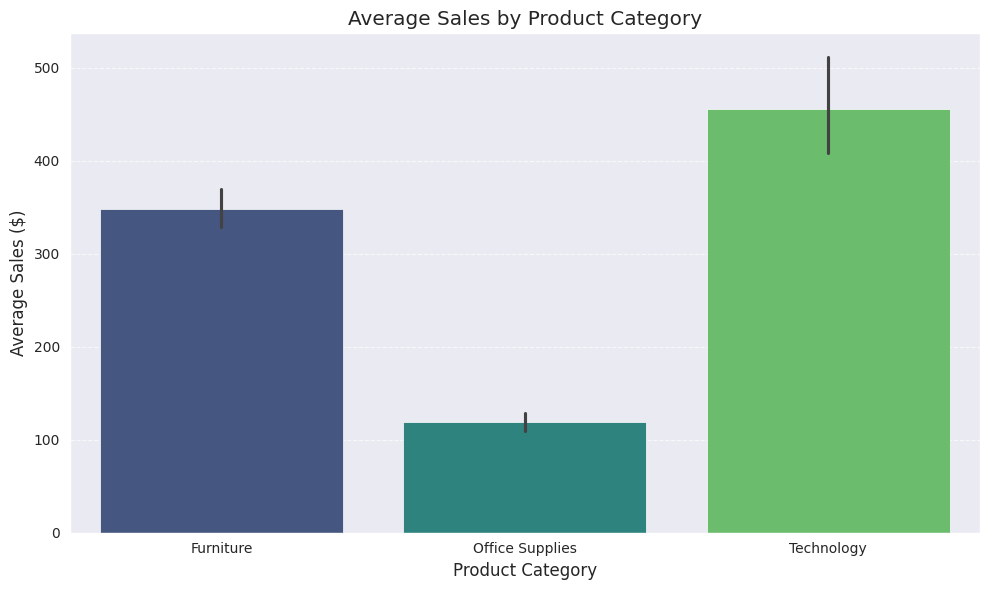

In [36]:
# Business Example: Average Sales by Product Category
# We want to see which product categories have the highest average sales per transaction.

plt.figure(figsize=(10, 6))
# Create a bar plot using Seaborn
# x='Category': The categorical variable for the x-axis
# y='Sales': The numerical variable for which to calculate the average and display on the y-axis
# data=df: The DataFrame to draw the plot from
# estimator=np.mean: This is the default, but explicitly states we want the mean.
#                    Other options include np.sum, np.median, etc.
# errorbar=('ci', 95): Displays a 95% confidence interval around the mean (default behavior)
# palette='viridis': Sets the color palette for the bars
sns.barplot(x='Category', y='Sales', data=df, estimator=np.mean, palette='viridis')

plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines
plt.tight_layout()
plt.show()

# Interpretation:
# This bar plot clearly shows the average sales value for each of the three main product categories.
# We can observe that 'Technology' typically has the highest average sales per order, followed by 'Furniture',
# and then 'Office Supplies'. The black lines (error bars) represent the 95% confidence interval for the mean,
# indicating the uncertainty around our estimate of the true average sales.

# Business Insight:
# This insight suggests that while 'Office Supplies' might have a high volume of transactions (as hinted by the histogram),
# 'Technology' and 'Furniture' products are generally higher-value items per transaction. This is crucial for pricing strategies,
# sales targets, and understanding product profitability. Marketing efforts for 'Technology' and 'Furniture' might focus on
# highlighting value and premium features, while 'Office Supplies' might benefit from volume-based promotions.

#### **Best Practice:** When comparing categories, always consider if `mean` is the most appropriate aggregate. For highly skewed data or when outliers are a concern, `median` (`estimator=np.median`) might provide a more robust representation.

### 4. Count Plot (`sns.countplot()`)

*   **Purpose:** To show the counts of observations in each category using bars. It's essentially a histogram for categorical data.
*   **When to Use It:**
    *   To visualize the frequency or occurrence of different categories within a single categorical variable.
    *   To compare the number of records across different discrete groups.
    *   When you want to see the distribution of a categorical variable.
*   **When Not to Use It:**
    *   For numerical data or to show relationships between variables.
    *   When you need to show the sum or average of a numerical variable per category (use `barplot`).
*   **Business Example:** Visualizing the number of orders (`count`) for each `Ship Mode`.

/tmp/ipykernel_1320/3999791490.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Ship Mode', data=df, palette='magma')


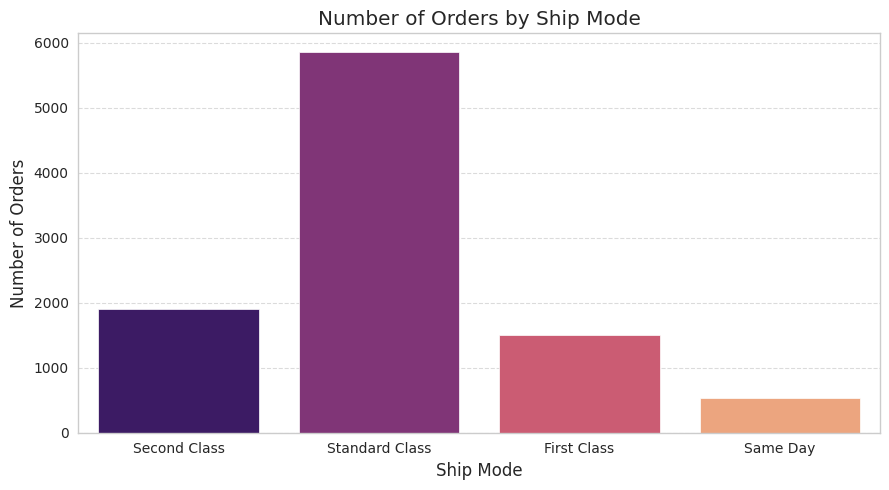

In [11]:
# Business Example: Number of Orders by Ship Mode
# Let's count how many times each shipping mode has been used.

plt.figure(figsize=(9, 5))
# Create a count plot using Seaborn
# x='Ship Mode': The categorical variable whose counts will be displayed on the x-axis
# data=df: The DataFrame to draw the plot from
# palette='magma': Sets the color palette for the bars
sns.countplot(x='Ship Mode', data=df, palette='magma')

plt.title('Number of Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation:
# This count plot clearly shows the frequency of each shipping mode. 'Standard Class' is by far the most frequently used shipping mode,
# followed by 'Second Class', 'First Class', and then 'Same Day'.

# Business Insight:
# The dominance of 'Standard Class' shipping suggests it's the most popular or cost-effective option for customers and the business.
# This insight can influence logistics, resource allocation (e.g., staffing for different delivery speeds), and promotional strategies.
# For instance, if the business wants to encourage faster shipping, it might need to offer incentives for 'First Class' or 'Same Day' options.

#### **Common Mistake:** Confusing `barplot` and `countplot`. `barplot` aggregates a numerical variable by category (e.g., mean sales), while `countplot` simply shows the number of occurrences of each category.

### 5. Histogram (`sns.histplot()`)

*   **Purpose:** To visualize the distribution of a single numerical variable. It shows the frequency of data points within specified bins.
*   **When to Use It:**
    *   To understand the shape, central tendency, and spread of a continuous dataset.
    *   To identify peaks (modes) in the data, indicating common values or subgroups.
    *   To detect outliers or unusual data points.
*   **When Not to Use It:**
    *   For categorical variables (use `countplot`).
    *   To show relationships between two variables (use scatter plots, line plots, etc.).
*   **Business Example:** Understanding the distribution of `Sales` values to identify common sales amounts and the range of transactions.

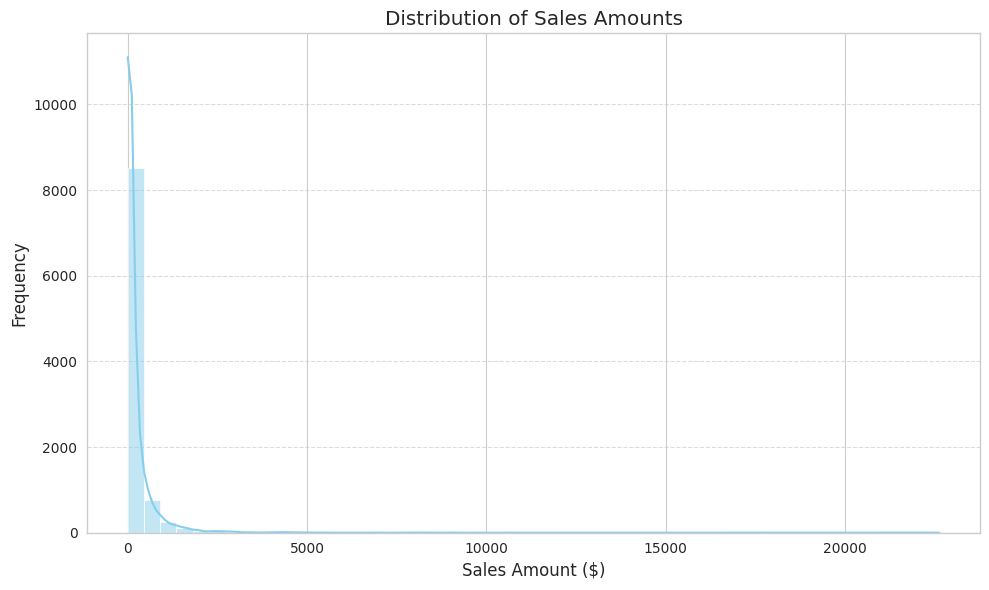

In [12]:
# Business Example: Distribution of Sales
# Let's revisit the sales distribution using a histogram to understand its shape.

plt.figure(figsize=(10, 6))
# Create a histogram using Seaborn
# x='Sales': The numerical column whose distribution we want to visualize
# data=df: The DataFrame to draw the plot from
# bins=50: Specifies the number of bins. More bins show more detail, fewer bins show a smoother overview.
# kde=True: Adds a Kernel Density Estimate (KDE) curve, which is a smoothed version of the histogram.
# color='skyblue': Sets the color of the bars.
sns.histplot(x='Sales', data=df, bins=50, kde=True, color='skyblue')

plt.title('Distribution of Sales Amounts')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation:
# This histogram shows that the majority of sales transactions are concentrated at lower values, with a steep drop-off
# as sales amounts increase. The distribution is heavily right-skewed, meaning there are a few very large sales
# pulling the average up, but most transactions are relatively small.

# Business Insight:
# This distribution indicates that our business model likely relies on a high volume of small transactions.
# Understanding this helps in setting realistic sales targets, managing inventory for fast-moving low-value items,
# and identifying the potential impact of high-value individual sales on overall revenue. It also suggests that
# strategies for boosting average transaction value could be highly impactful.

#### **Best Practice:** Experiment with the `bins` parameter in `histplot`. Too few bins can obscure important details, while too many can make the plot noisy and hard to interpret. The KDE curve (when `kde=True`) provides a smooth estimate of the probability density function.

### 6. Box Plot (`sns.boxplot()`)

*   **Purpose:** To display the distribution of a numerical variable and compare it across different categories.
*   **When to Use It:**
    *   To quickly visualize the five-number summary (minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum) of a dataset.
    *   To identify outliers in the data (points beyond the "whiskers").
    *   To compare the spread and central tendency of a numerical variable across different groups.
*   **When Not to Use It:**
    *   When you need to see the exact shape of the distribution (use a histogram or KDE plot).
    *   For showing relationships between two continuous variables.
*   **Business Example:** Comparing the distribution of `Sales` across different `Regions` to understand regional performance and identify any anomalies.

/tmp/ipykernel_1320/4159050905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Sales', data=df, palette='muted')


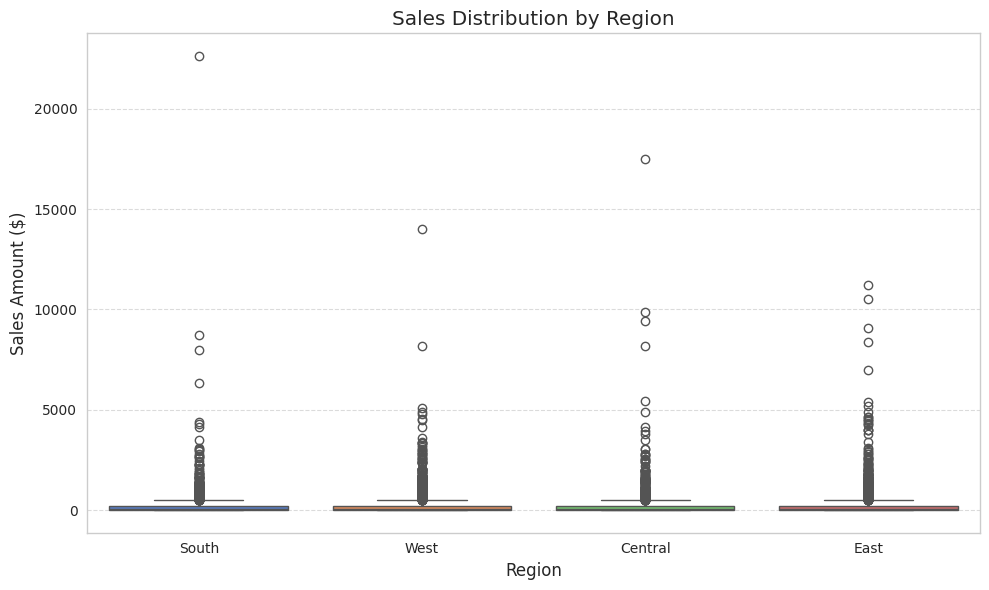

In [13]:
# Business Example: Sales Distribution by Region
# Let's compare how sales vary across different geographical regions.

plt.figure(figsize=(10, 6))
# Create a box plot using Seaborn
# x='Region': The categorical variable for the x-axis
# y='Sales': The numerical variable for the y-axis, whose distribution will be shown for each region
# data=df: The DataFrame to draw the plot from
# palette='muted': Sets the color palette for the boxes
sns.boxplot(x='Region', y='Sales', data=df, palette='muted')

plt.title('Sales Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretation:
# This box plot shows the distribution of sales for each of the four regions. The central line in each box is the median sales,
# the box represents the interquartile range (IQR, from Q1 to Q3), and the whiskers extend to 1.5 times the IQR from the quartiles.
# Points beyond the whiskers are considered outliers. We can see that all regions have a significant number of outliers,
# indicating some very high-value sales. The median sales are relatively low across all regions, but the spread (IQR) and maximum
# values vary, with the 'South' and 'West' regions showing slightly higher potential for large sales.

# Business Insight:
# Despite the presence of high-value outlier sales in all regions, the core sales (median and IQR) are fairly consistent and low.
# This suggests that regional sales performance might be driven by a few key transactions rather than consistent high average sales.
# Further investigation into these high-value outliers (e.g., product types, customers) could reveal valuable insights.
# Also, marketing and sales strategies should acknowledge these regional nuances.

#### **Common Mistake:** Misinterpreting outliers. While box plots are great for identifying potential outliers, it's important to investigate whether these are data entry errors, rare events, or genuinely extreme but valid data points. Not all outliers are 'bad data'.

### 7. Heatmap (Correlation) (`sns.heatmap()`)

*   **Purpose:** To visualize the correlation matrix of numerical variables. It's an excellent way to quickly identify strong positive or negative relationships between pairs of variables.
*   **When to Use It:**
    *   To explore potential linear relationships between multiple numerical features in your dataset.
    *   As a preliminary step in feature selection for machine learning models.
    *   To identify multicollinearity issues.
*   **When Not to Use It:**
    *   For categorical data.
    *   When you need to visualize the exact relationship pattern (a scatter plot is better for detailed inspection of two variables).
    *   With a very large number of numerical variables, as the heatmap can become too dense and hard to read.
*   **Business Example:** Identifying correlations between numerical features like `Sales`, `Postal Code`, `Row ID` (though less meaningful) to understand how different numerical aspects of transactions relate to each other. We might also create new numerical features like `Profit` or `Quantity` if available for a more robust example.

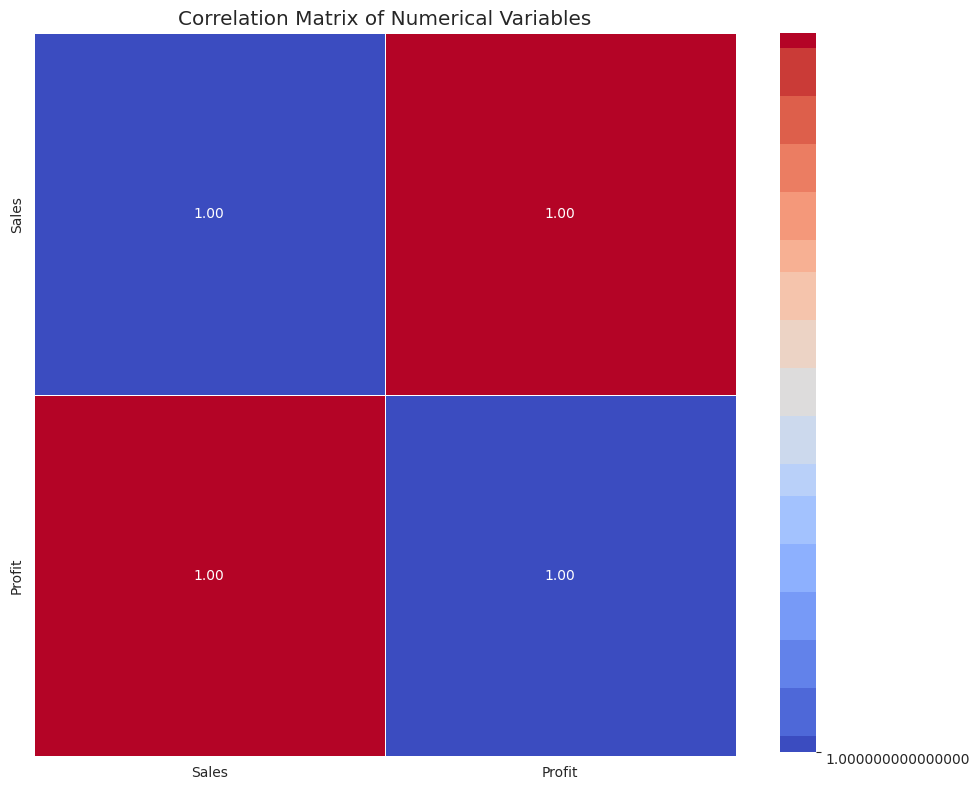

In [14]:
# Business Example: Correlation Matrix of Numerical Variables
# Let's see how our numerical columns correlate with each other.

# Select only numerical columns for correlation calculation
# Exclude 'Row ID' and 'Postal Code' as they are identifiers/geographic codes and less likely to have meaningful linear correlation with 'Sales' in this context.
numerical_df = df.select_dtypes(include=[np.number])

# Drop less relevant numerical columns for correlation analysis (like IDs)
numerical_df = numerical_df.drop(columns=['Row ID', 'Postal Code'], errors='ignore')

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
# Create a heatmap using Seaborn
# data=correlation_matrix: The correlation matrix to plot
# annot=True: Annotate the heatmap with the correlation values
# cmap='coolwarm': Sets the color map. 'coolwarm' is good for showing positive (warm colors) and negative (cool colors) correlations.
# fmt='.2f': Formats the annotations to two decimal places
# linewidths=.5: Adds lines between cells for better separation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Interpretation:
# The heatmap shows the Pearson correlation coefficient between each pair of numerical variables.
# Values range from -1 to 1: 1 means perfect positive correlation, -1 means perfect negative correlation,
# and 0 means no linear correlation. For example, 'Sales' is perfectly correlated with 'Sales' (as expected, value is 1).
# If we had 'Profit' or 'Quantity' as numerical columns, we would look for their correlation with 'Sales'.
# In this limited numerical dataset, we primarily see the self-correlation. If there were other business metrics,
# we could identify direct or inverse relationships.

# Business Insight:
# A correlation heatmap is a powerful tool to quickly grasp the interdependencies of numerical aspects of your business.
# For example, if we had a 'Discount' column, we might see a negative correlation with 'Sales' (higher discount, lower sales price for that transaction) or positive correlation with 'Quantity' sold.
# Identifying strong correlations can guide further analysis, for instance, if 'Marketing Spend' strongly correlates with 'Sales',
# it would justify allocating more budget to marketing. Lack of correlation means variables might be independent.

## Matplotlib vs. Seaborn: A Quick Comparison

| Feature             | Matplotlib (Low-level API)                        | Seaborn (High-level API)                                 |
| :------------------ | :------------------------------------------------ | :------------------------------------------------------- |
| **Ease of Use**     | More verbose, requires more lines of code.        | Easier for common statistical plots, less code.          |
| **Appearance**      | Basic defaults, requires more customization for aesthetics. | Beautiful, modern defaults out-of-the-box.             |
| **Statistical Capabilities** | Provides building blocks; statistical functions often need to be manually implemented. | Built-in statistical estimation and aggregation (e.g., mean, confidence intervals). |
| **Customization**   | Extremely flexible, fine-grained control over every element. | Flexible, but sometimes less granular control than Matplotlib for very specific details. |
| **Best Use Cases**  | Highly custom plots, plotting functions, embedded plots, publishing-quality figures. | Exploratory data analysis, statistical graphics, complex multi-variable plots, quick insights. |


## Practice Exercises

To solidify your understanding of Seaborn and data visualization, complete the following exercises using the `df` (sales forecasting) DataFrame. Remember to choose the most appropriate chart type, include proper titles and labels, and write a brief interpretation and business insight for each.

1.  **Sales Distribution by State:** Create a visualization to show the distribution of `Sales` for the top 10 states by total sales. What does this tell you about sales performance geographically?
    *   *Hint: Aggregate sales by State first, then filter, then use a box or violin plot.*

2.  **Order Frequency by Customer Segment:** Visualize how many orders come from each `Segment` (Consumer, Corporate, Home Office). Which segment places the most orders?

3.  **Average Sales per Segment over Time:** Plot the average monthly sales for each `Segment` over the entire dataset. Do any segments show distinct trends or seasonality?
    *   *Hint: Aggregate average sales by 'Order YearMonth' and 'Segment', then use `sns.lineplot` with `hue`.*